In [5]:
from langgraph.graph import StateGraph, MessagesState, START, END

In [6]:
from pydantic import BaseModel
from typing import Annotated, List

class AgentState(BaseModel):
    state_id: str
    question: str
    plan: List[str]
    execute: bool
    direct_ans: bool
    proper_ans: bool


In [8]:
def planner():
    pass

def executor():
    pass


def should_execute(state: AgentState) -> AgentState:
    if state["execute"]:
        return "do_execute"
    else:
        return "no_execute"


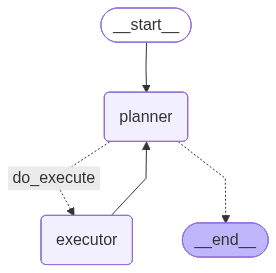

In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node("planner", planner)
workflow.add_node("executor", executor)

workflow.set_entry_point("planner")
workflow.add_conditional_edges(
    "planner",
    should_execute,
    {
        "do_execute": "executor",
    }
)

workflow.add_edge("executor", "planner")
workflow.add_edge("planner", END)
app = workflow.compile()
app


In [ ]:
class AgentState(BaseModel):
    state_id: str
    question: str
    tools: List[str]
    memory: List[str]
    ltm: List[str]

workflow = StateGraph(AgentState)

workflow.add_node("planner", planner)
workflow.add_node("executor", executor)

workflow.set_entry_point("planner")
workflow.add_conditional_edges(
    "planner",
    should_execute,
    {
        "do_execute": "executor",
    }
)

workflow.add_edge("executor", "planner")
workflow.add_edge("planner", END)
app = workflow.compile()
app


In [3]:
class Agent_one(BaseModel):
    state_id: str
    question: str
    planner: List[str]

class Agent_two(BaseModel):
    plan: List[str]
    tools: List[str]
    